# Step 1: Problem Definition

## 1.1 Business Context & Objective
In this project, I am working with an aviation company offering both domestic and international travel services that wants to improve its customer acquisition strategy. Traditionally, their outreach has relied on broad-based methods like telecalling, which are costly and less effective.  

To modernize their approach, the company partnered with a social networking platform to leverage customer digital and social behavior for targeted advertising. Because running ads on digital platforms is expensive, my objective is to focus marketing efforts exclusively on customers who are most likely to take up the travel product and purchase tickets.

## 1.2 Machine Learning Problem Type
- **Problem Category:** Supervised Learning  
- **Task Type:** Binary Classification & Propensity Scoring  
- **Target Variable:** `Taken_product`  
  - `0` = Will not take product / buy next month  
  - `1` = Will take product / buy next month  
- **Output Requirement:** Instead of hard classification predictions (just 0 or 1), I will train my models to output a **propensity score** (probability between 0.0 and 1.0). This allows the marketing team to rank potential leads and serve advertisements only to the highest-converting segments.

## 1.3 Key Structural Constraint: Device Segmentation
Since device usage significantly influences purchasing patterns, my task requires developing two separate predictive models:  
- **Laptop Users Model** - **Mobile Users Model**

## 1.4 Success Criteria & Evaluation Strategy
Standard classification accuracy is not enough for cost-sensitive ad targeting. I will evaluate model success using:

- **Ranking Metrics (ROC-AUC & Precision-Recall AUC):** To evaluate how effectively my models separate actual buyers from non-buyers across different probability thresholds.

- **Business ROI via Cumulative Gain & Lift Charts:** To measure business value directly by showing what percentage of total actual product takers can be captured if the company only targets the top 10%, 20%, or 30% of users ranked by my model.

In [1]:
# ==========================================
# STEP 1: SETUP & PROBLEM VALIDATION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [2]:
# Set visual style for plots
sns.set_theme(style="whitegrid")

# Search for all files inside the Kaggle input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/shayanazmi05/flight-customer-data/flight_customer_data.xlsx


In [3]:
import pandas as pd

# Paste the exact path printed by the os.walk check above
file_path = "/kaggle/input/datasets/shayanazmi05/flight-customer-data/flight_customer_data.xlsx"

# Use read_csv if the printed file ends in .csv, or read_excel if it ends in .xlsx
try:
    df = pd.read_csv(file_path)
except:
    df = pd.read_excel(file_path)

print("Dataset successfully loaded! Shape:", df.shape)
display(df.head())

Dataset successfully loaded! Shape: (11760, 17)


,UserID,Taken_product,Yearly_avg_view_on_travel_page,preferred_device,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
0,1000001,Yes,307.0,iOS and Android,38570.0,1,2,Financial,94.0,5993,8,Yes,11,No,1,0,8
1,1000002,No,367.0,iOS,9765.0,1,1,Financial,61.0,5130,1,No,23,Yes,4,1,10
2,1000003,Yes,277.0,iOS and Android,48055.0,1,2,Other,92.0,2090,6,Yes,15,No,2,0,7
3,1000004,No,247.0,iOS,48720.0,1,4,Financial,56.0,2909,1,Yes,11,No,3,0,8
4,1000005,No,202.0,iOS and Android,20685.0,1,1,Medical,40.0,3468,9,No,12,No,4,1,6


In [4]:

# 2. Validate Dataset Shape & Initial View
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head(3))

Dataset Shape: 11760 rows, 17 columns



,UserID,Taken_product,Yearly_avg_view_on_travel_page,preferred_device,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag,Daily_Avg_mins_spend_on_traveling_page
0,1000001,Yes,307.0,iOS and Android,38570.0,1,2,Financial,94.0,5993,8,Yes,11,No,1,0,8
1,1000002,No,367.0,iOS,9765.0,1,1,Financial,61.0,5130,1,No,23,Yes,4,1,10
2,1000003,Yes,277.0,iOS and Android,48055.0,1,2,Other,92.0,2090,6,Yes,15,No,2,0,7


In [5]:

# 1. Strip any accidental whitespace from all column names
df.columns = df.columns.str.strip()

# 2. Drop UserID as it is just an ID number and has no predictive power
if 'UserID' in df.columns:
    df = df.drop(columns=['UserID'])

# 3. Convert the TARGET VARIABLE (Taken_product) from Yes/No to 1/0
df['Taken_product'] = df['Taken_product'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(0).astype(int)

# 4. Convert other Yes/No feature columns to binary 0/1
binary_cols = ['following_company_page', 'working_flag', 'Adult_flag']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(0).astype(int)

# 5. Create new behavioral feature variables
df['brand_affinity_ratio'] = df['montly_avg_comment_on_company_page'] / (df['Yearly_avg_comment_on_travel_page'] + 1e-5)
df['total_social_likes'] = df['total_likes_on_outstation_checkin_given'] + df['total_likes_on_outofstation_checkin_received']

# Verify our target variable distribution
print("=== Target Variable (Taken_product) Breakdown ===")
print(df['Taken_product'].value_counts(normalize=True) * 100)
print("\n=== Unique Devices in Dataset ===")
print(df['preferred_device'].value_counts())

=== Target Variable (Taken_product) Breakdown ===
Taken_product
0    83.877551
1    16.122449
Name: proportion, dtype: float64

=== Unique Devices in Dataset ===
preferred_device
Tab                4172
iOS and Android    4134
Laptop             1108
iOS                1095
Mobile              600
Android             315
Android OS          145
ANDROID             134
Other                 2
Others                2
Name: count, dtype: int64


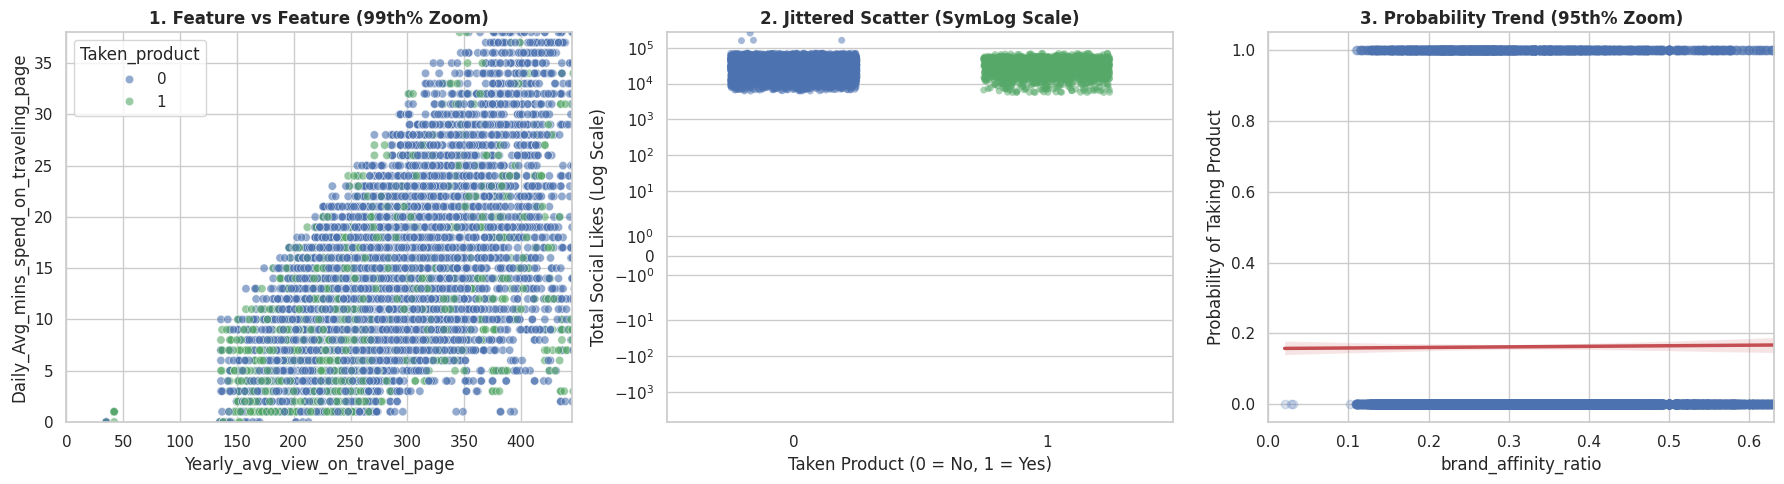

In [6]:


# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# 1. THREE WAYS TO USE SCATTER PLOTS (DYNAMIC SCALING)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Technique 1: 2D Feature Scatter (with 99th Percentile Axis Bounding)
sns.scatterplot(
    data=df, 
    x='Yearly_avg_view_on_travel_page', 
    y='Daily_Avg_mins_spend_on_traveling_page', 
    hue='Taken_product', 
    palette={0: '#4c72b0', 1: '#55a868'}, 
    alpha=0.6, 
    ax=axes[0]
)
# Dynamic scaling: clip axes to 99th percentile to prevent extreme outliers from compressing the cluster
axes[0].set_xlim(0, df['Yearly_avg_view_on_travel_page'].quantile(0.99))
axes[0].set_ylim(0, df['Daily_Avg_mins_spend_on_traveling_page'].quantile(0.99))
axes[0].set_title('1. Feature vs Feature (99th% Zoom)', fontweight='bold')

# Technique 2: Jittered Strip Plot (with SymLog Scaling for Heavy-Tailed Likes)
sns.stripplot(
    data=df, 
    x='Taken_product', 
    y='total_social_likes', 
    hue='Taken_product',
    palette={0: '#4c72b0', 1: '#55a868'}, 
    jitter=0.25, 
    alpha=0.5, 
    legend=False,
    ax=axes[1]
)
# Dynamic scaling: symlog spreads out both low-engagement and viral-like counts without breaking on 0
axes[1].set_yscale('symlog')
axes[1].set_title('2. Jittered Scatter (SymLog Scale)', fontweight='bold')
axes[1].set_xlabel('Taken Product (0 = No, 1 = Yes)')
axes[1].set_ylabel('Total Social Likes (Log Scale)')

# Technique 3: Scatter with Logistic Probability Trend (with 95th Percentile Filtering)
# We calculate the 95th percentile cutoff to prevent division-by-zero ratio spikes from flattening the curve
max_ratio = df['brand_affinity_ratio'].quantile(0.95)
sns.regplot(
    data=df[df['brand_affinity_ratio'] <= max_ratio], 
    x='brand_affinity_ratio', 
    y='Taken_product', 
    logistic=True, 
    scatter_kws={'alpha': 0.2, 'color': '#4c72b0'}, 
    line_kws={'color': '#c44e52', 'linewidth': 2.5}, 
    ax=axes[2]
)
axes[2].set_xlim(0, max_ratio)
axes[2].set_title('3. Probability Trend (95th% Zoom)', fontweight='bold')
axes[2].set_ylabel('Probability of Taking Product')

plt.tight_layout()
plt.show()

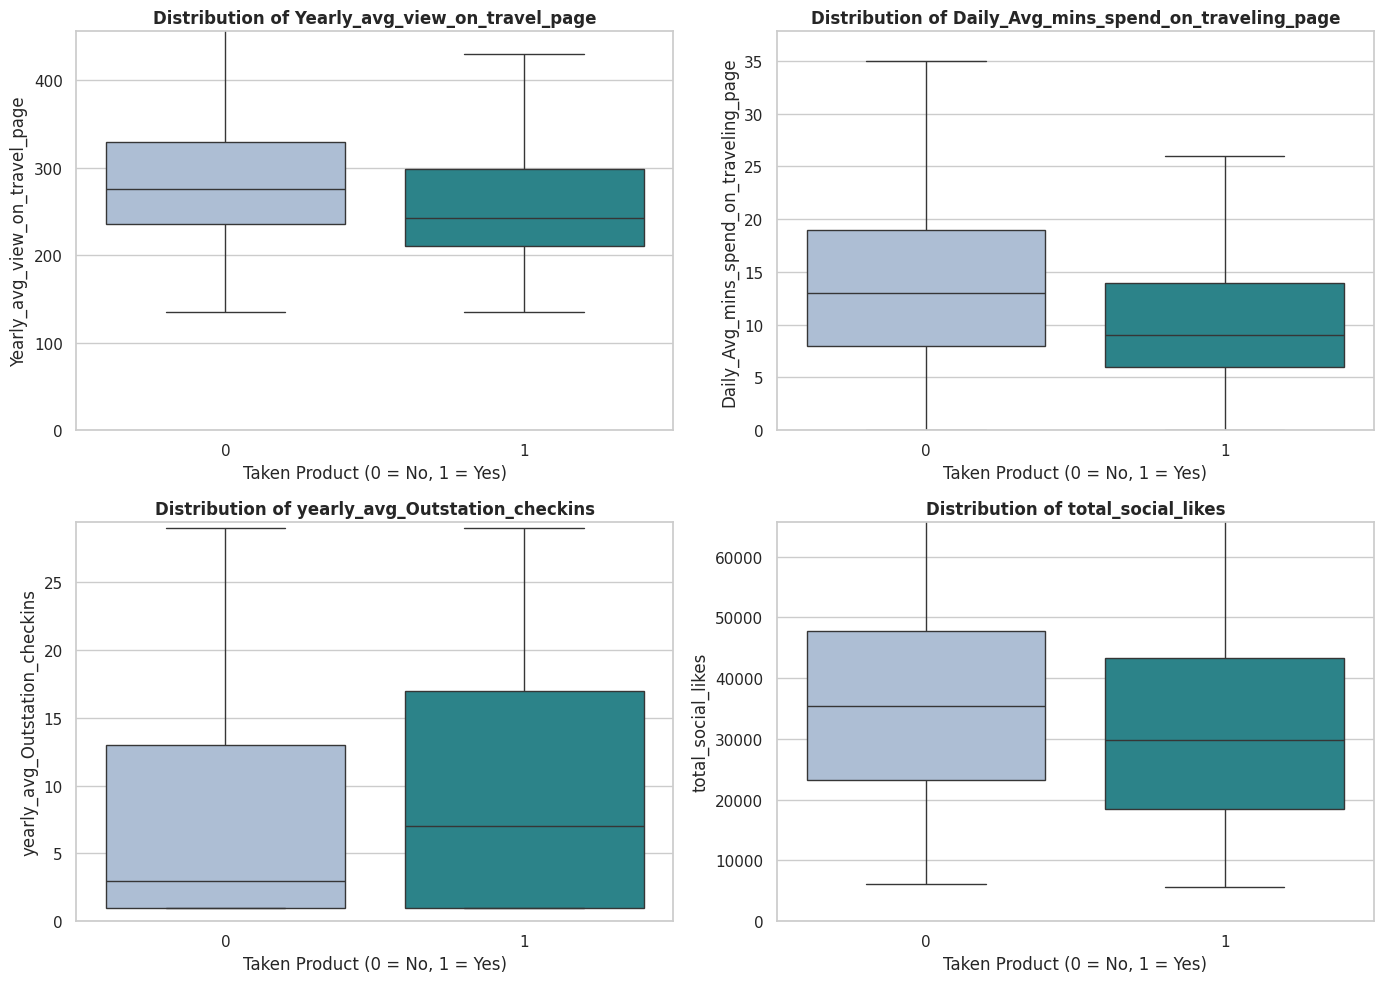

In [7]:
# ==========================================
# 2. BOXPLOTS: FEATURE COMPARISONS BY TARGET
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

key_features = [
    'Yearly_avg_view_on_travel_page', 
    'Daily_Avg_mins_spend_on_traveling_page', 
    'yearly_avg_Outstation_checkins', 
    'total_social_likes'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if col in df.columns:
        # 1. FORCE NUMERIC TYPE: Coerce strings to numbers, invalid text becomes NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # 2. Plot the boxplot
        sns.boxplot(
            data=df, 
            x='Taken_product', 
            y=col, 
            hue='Taken_product',
            palette={0: "#a6bddb", 1: "#1c9099"}, 
            showfliers=False,  # Hides outlier dots
            legend=False,
            ax=axes[i]
        )
        
        # 3. Dynamic Y-Axis Scaling: Drop NaNs so quantile comparison never crashes
        upper_limit = df[col].dropna().quantile(0.98)
        
        # Prevent edge case errors if a column is empty or all 0s
        if pd.notna(upper_limit) and upper_limit > 0:
            axes[i].set_ylim(0, upper_limit * 1.05)
        
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].set_xlabel('Taken Product (0 = No, 1 = Yes)')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [8]:


# 1. Ensure numeric types for ratio math (prevents string comparison errors)
df['montly_avg_comment_on_company_page'] = pd.to_numeric(df['montly_avg_comment_on_company_page'], errors='coerce').fillna(0)
df['Yearly_avg_comment_on_travel_page'] = pd.to_numeric(df['Yearly_avg_comment_on_travel_page'], errors='coerce').fillna(0)
df['total_likes_on_outstation_checkin_given'] = pd.to_numeric(df['total_likes_on_outstation_checkin_given'], errors='coerce').fillna(0)
df['total_likes_on_outofstation_checkin_received'] = pd.to_numeric(df['total_likes_on_outofstation_checkin_received'], errors='coerce').fillna(0)

# 2. Create new behavioral features
# Add a small epsilon (1e-5) to avoid division by zero
df['brand_affinity_ratio'] = df['montly_avg_comment_on_company_page'] / (df['Yearly_avg_comment_on_travel_page'] + 1e-5)
df['total_social_likes'] = df['total_likes_on_outstation_checkin_given'] + df['total_likes_on_outofstation_checkin_received']

# 3. Step 3.1: Bifurcate dataset based on preferred_device
# Using regex case-insensitive search to catch "Laptop", "iOS and Android", "Mobile", etc.
df_laptop = df[df['preferred_device'].astype(str).str.contains('laptop|mac|pc|desktop', case=False, na=False)].copy()
df_mobile = df[df['preferred_device'].astype(str).str.contains('mobile|ios|android|phone|ipad|tab', case=False, na=False)].copy()
# Drop preferred_device column as it's now redundant in split datasets
df_laptop = df_laptop.drop(columns=['preferred_device'])
df_mobile = df_mobile.drop(columns=['preferred_device'])

print(f"Laptop Cohort Shape: {df_laptop.shape}")
print(f"Mobile Cohort Shape: {df_mobile.shape}")

Laptop Cohort Shape: (1108, 17)
Mobile Cohort Shape: (10595, 17)


/tmp/ipykernel_23/410125265.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Laptop Users', 'Mobile Users'], y=[laptop_conv, mobile_conv], palette='viridis')


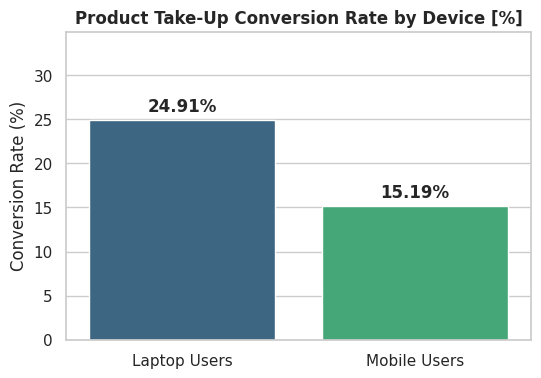

In [9]:

# Compare baseline product conversion rates using Taken_product
laptop_conv = df_laptop['Taken_product'].mean() * 100
mobile_conv = df_mobile['Taken_product'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=['Laptop Users', 'Mobile Users'], y=[laptop_conv, mobile_conv], palette='viridis')
plt.title('Product Take-Up Conversion Rate by Device [%]', fontsize=12, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, max(laptop_conv, mobile_conv) + 10)

for i, v in enumerate([laptop_conv, mobile_conv]):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

=== Q1 Executive Summary: Brand Following Impact ===
Does Not Follow: 10.52% conversion across 8463 users
Follows Company Page: 30.51% conversion across 3297 users


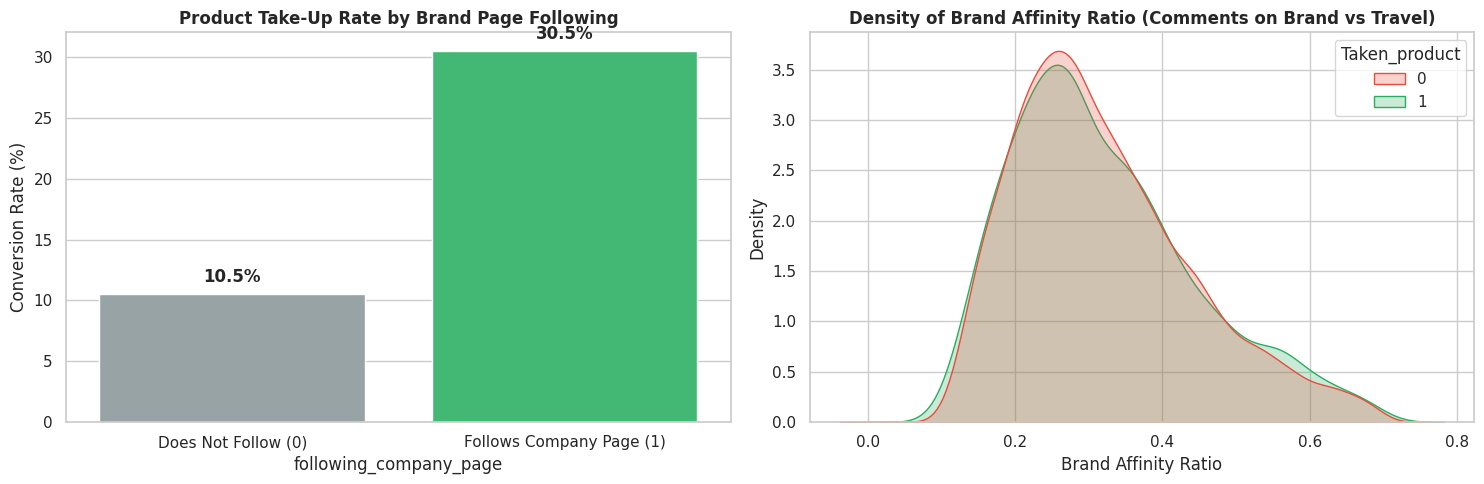

In [10]:
# ==============================================================================
# Q1: BRAND AFFINITY VS GENERAL TRAVEL CURIOSITY (UPDATED & FIXED)
# ==============================================================================


sns.set_theme(style="whitegrid", palette="muted")

# 1. Clean and coerce numeric types safely
df['following_company_page'] = pd.to_numeric(df['following_company_page'], errors='coerce').fillna(0).astype(int)
df['montly_avg_comment_on_company_page'] = pd.to_numeric(df['montly_avg_comment_on_company_page'], errors='coerce').fillna(0)
df['Yearly_avg_comment_on_travel_page'] = pd.to_numeric(df['Yearly_avg_comment_on_travel_page'], errors='coerce').fillna(0)
df['brand_affinity_ratio'] = df['montly_avg_comment_on_company_page'] / (df['Yearly_avg_comment_on_travel_page'] + 1e-5)

# 2. Statistical summary
brand_conv = df.groupby('following_company_page')['Taken_product'].agg(['count', 'mean']).reset_index()
brand_conv['conversion_rate'] = brand_conv['mean'] * 100
print("=== Q1 Executive Summary: Brand Following Impact ===")
for _, row in brand_conv.iterrows():
    status = "Follows Company Page" if row['following_company_page'] == 1 else "Does Not Follow"
    print(f"{status}: {row['conversion_rate']:.2f}% conversion across {int(row['count'])} users")

# 3. Visualization Grid
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Conversion Rate by Brand Following Status
# FIXED: Assigned hue='following_company_page' and legend=False to comply with new Seaborn rules
sns.barplot(
    data=brand_conv, 
    x='following_company_page', 
    y='conversion_rate', 
    hue='following_company_page',
    palette=["#95a5a6", "#2ecc71"], 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Product Take-Up Rate by Brand Page Following', fontweight='bold', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Does Not Follow (0)', 'Follows Company Page (1)'])
axes[0].set_ylabel('Conversion Rate (%)')
for i, val in enumerate(brand_conv['conversion_rate']):
    axes[0].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# Right: Brand Affinity Ratio Distribution
max_val = df['brand_affinity_ratio'].quantile(0.95)
sns.kdeplot(
    data=df[df['brand_affinity_ratio'] <= max_val], 
    x='brand_affinity_ratio', 
    hue='Taken_product', 
    fill=True, 
    common_norm=False, 
    palette={0: "#e74c3c", 1: "#27ae60"}, 
    ax=axes[1]
)
axes[1].set_title('Density of Brand Affinity Ratio (Comments on Brand vs Travel)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Brand Affinity Ratio')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

=== Q2 Executive Summary: Traveling Network Rating ===
 travelling_network_rating  count  conversion_rate
                         1   2208        20.652174
                         2   2424        14.851485
                         3   3672        15.468410
                         4   3456        14.814815


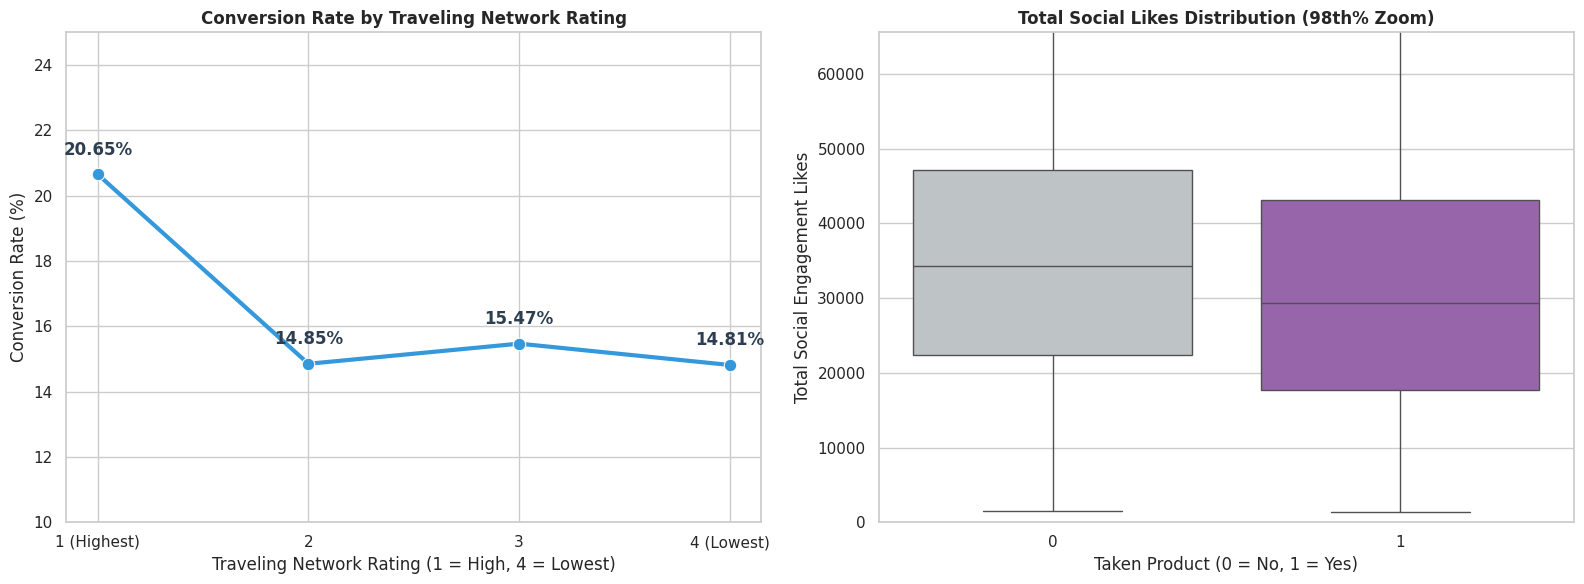

In [11]:
# ==============================================================================
# Q2: SOCIAL PROOF & PEER NETWORK INFLUENCE (DYNAMIC SCALING UPDATED)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# 1. Ensure numeric types
df['travelling_network_rating'] = pd.to_numeric(df['travelling_network_rating'], errors='coerce')
df['total_social_likes'] = pd.to_numeric(df['total_likes_on_outstation_checkin_given'], errors='coerce').fillna(0) + \
                           pd.to_numeric(df['total_likes_on_outofstation_checkin_received'], errors='coerce').fillna(0)

# 2. Statistical summary by Network Rating
net_conv = df.groupby('travelling_network_rating')['Taken_product'].agg(['count', 'mean']).reset_index()
net_conv['conversion_rate'] = net_conv['mean'] * 100
print("=== Q2 Executive Summary: Traveling Network Rating ===")
print(net_conv[['travelling_network_rating', 'count', 'conversion_rate']].to_string(index=False))

# 3. Visualization Grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Conversion by Network Rating (with Focused Y-Axis Window & Direct Labels)
sns.lineplot(
    data=net_conv, 
    x='travelling_network_rating', 
    y='conversion_rate', 
    marker='o', 
    color='#3498db', 
    linewidth=3, 
    markersize=9, 
    ax=axes[0]
)
axes[0].set_title('Conversion Rate by Traveling Network Rating', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Traveling Network Rating (1 = High, 4 = Lowest)')
axes[0].set_ylabel('Conversion Rate (%)')

# Dynamic Range Scale: Lock y-axis window between 10% and 25% to emphasize variance
axes[0].set_ylim(10, 25)
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(['1 (Highest)', '2', '3', '4 (Lowest)'])

# Add direct percentage labels above each data marker
for _, row in net_conv.iterrows():
    axes[0].text(
        row['travelling_network_rating'], 
        row['conversion_rate'] + 0.6, 
        f"{row['conversion_rate']:.2f}%", 
        ha='center', 
        fontweight='bold', 
        color='#2c3e50'
    )

# Right: Social Likes Distribution (with 98th Percentile Clipping to prevent squishing)
sns.boxplot(
    data=df, 
    x='Taken_product', 
    y='total_social_likes', 
    hue='Taken_product',
    palette=["#bdc3c7", "#9b59b6"], 
    showfliers=False, 
    legend=False,
    ax=axes[1]
)

# Dynamic Range Scale: Cap y-axis at the 98th percentile of total likes
upper_limit = df['total_social_likes'].quantile(0.98)
if pd.notna(upper_limit) and upper_limit > 0:
    axes[1].set_ylim(0, upper_limit * 1.05)

axes[1].set_title('Total Social Likes Distribution (98th% Zoom)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Taken Product (0 = No, 1 = Yes)')
axes[1].set_ylabel('Total Social Engagement Likes')

plt.tight_layout()
plt.show()

=== Q3 Executive Summary: Persona Conversion Rates (%) ===
working_flag                 0      1
preferred_location_type              
Beach                    14.12  17.71
Big Cities               23.91   9.52
Entertainment            22.05  35.82
Financial                14.11  17.80
Game                      9.09   0.00
Hill Stations            25.00  33.33
Historical site          13.88  12.00
Medical                  13.97  12.04
Movie                    25.00   0.00
OTT                      57.14    NaN
Other                    13.35  14.41
Social media             23.86   9.52
Tour  Travel             22.22  33.33
Tour and Travel          29.27  33.33
Trekking                 22.61  35.29


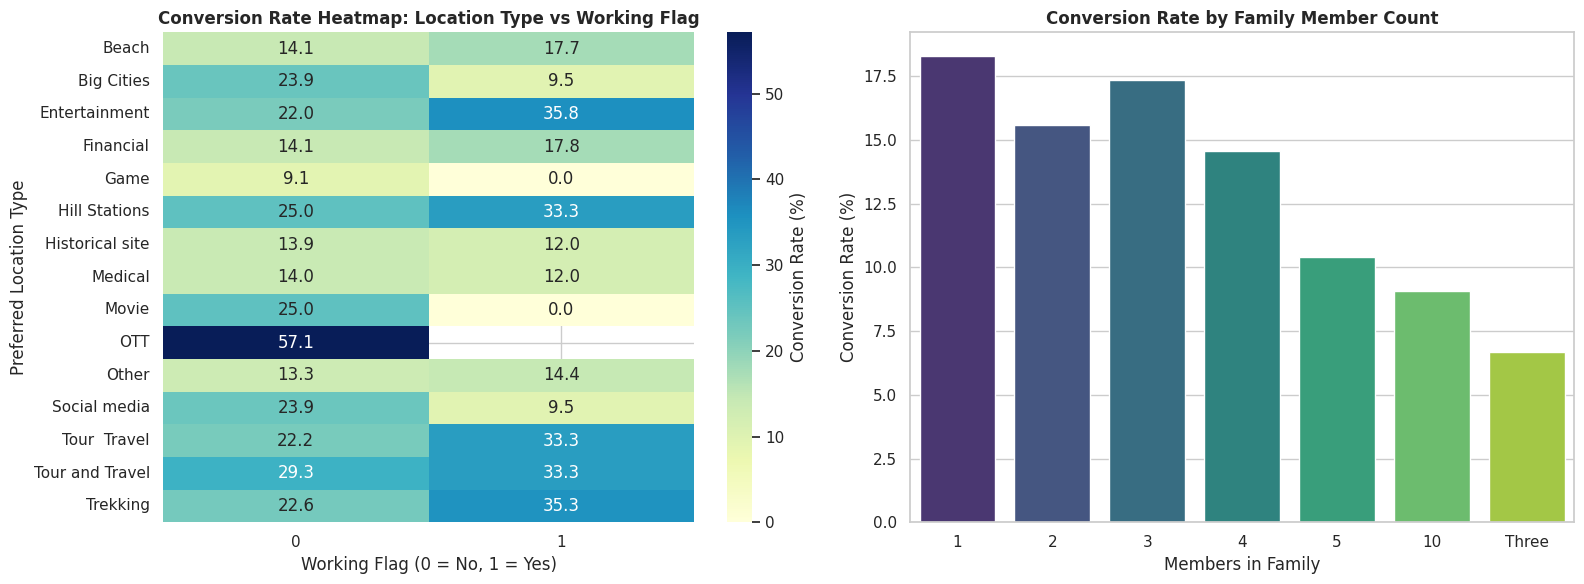

In [12]:
# ==============================================================================
# Q3: DEMOGRAPHIC & LIFESTYLE SEGMENTATION (UPDATED)
# ==============================================================================
df['working_flag'] = pd.to_numeric(df['working_flag'], errors='coerce').fillna(0).astype(int)

# 1. Heatmap Data: Location Type vs Working Flag Conversion Rate
pivot_conv = df.pivot_table(
    index='preferred_location_type', 
    columns='working_flag', 
    values='Taken_product', 
    aggfunc='mean'
) * 100

print("=== Q3 Executive Summary: Persona Conversion Rates (%) ===")
print(pivot_conv.round(2))

# 2. Visualization Grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Heatmap of Conversion by Working Status and Location
sns.heatmap(
    pivot_conv, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Conversion Rate (%)'}, 
    ax=axes[0]
)
axes[0].set_title('Conversion Rate Heatmap: Location Type vs Working Flag', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Working Flag (0 = No, 1 = Yes)')
axes[0].set_ylabel('Preferred Location Type')

# Right: Family Size Impact
fam_conv = df.groupby('member_in_family')['Taken_product'].mean().reset_index()
fam_conv['conversion_rate'] = fam_conv['Taken_product'] * 100
sns.barplot(
    data=fam_conv, 
    x='member_in_family', 
    y='conversion_rate', 
    hue='member_in_family',
    palette='viridis', 
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Conversion Rate by Family Member Count', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Members in Family')
axes[1].set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

=== Q4 Executive Summary: Recency Sweet Spot ===
recency_bin  count  conversion_rate
  0-2 Weeks   4770        16.477987
  3-4 Weeks   2884        13.037448
  5-8 Weeks   2404        19.467554
 9-12 Weeks    670        21.194030
  12+ Weeks      0              NaN


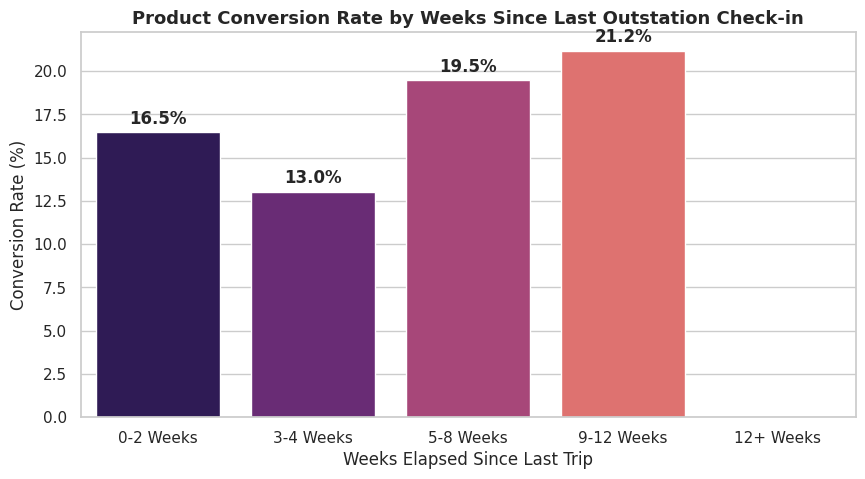

In [13]:
# ==============================================================================
# Q4: TRAVEL RECENCY & THE "TRAVEL HUNGER" WINDOW (UPDATED)
# ==============================================================================
df['week_since_last_outstation_checkin'] = pd.to_numeric(df['week_since_last_outstation_checkin'], errors='coerce')
df['yearly_avg_Outstation_checkins'] = pd.to_numeric(df['yearly_avg_Outstation_checkins'], errors='coerce')

# 1. Create Recency Bins to identify the sweet spot
df['recency_bin'] = pd.cut(
    df['week_since_last_outstation_checkin'], 
    bins=[0, 2, 4, 8, 12, 52], 
    labels=['0-2 Weeks', '3-4 Weeks', '5-8 Weeks', '9-12 Weeks', '12+ Weeks']
)

rec_conv = df.groupby('recency_bin', observed=False)['Taken_product'].agg(['count', 'mean']).reset_index()
rec_conv['conversion_rate'] = rec_conv['mean'] * 100

print("=== Q4 Executive Summary: Recency Sweet Spot ===")
print(rec_conv[['recency_bin', 'count', 'conversion_rate']].to_string(index=False))

# 2. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(
    data=rec_conv, 
    x='recency_bin', 
    y='conversion_rate', 
    hue='recency_bin',
    palette='magma',
    legend=False
)
plt.title('Product Conversion Rate by Weeks Since Last Outstation Check-in', fontweight='bold', fontsize=13)
plt.xlabel('Weeks Elapsed Since Last Trip')
plt.ylabel('Conversion Rate (%)')
for i, val in enumerate(rec_conv['conversion_rate']):
    if pd.notna(val):
        plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontweight='bold')
plt.show()

=== Q5 Executive Summary: Cross-Device Behavioral Profiles ===
              Daily_Avg_mins_spend_on_traveling_page  \
device_group                                           
Laptop User                                    13.63   
Mobile User                                    13.84   

              Yearly_avg_view_on_travel_page  Conversion Rate (%)  
device_group                                                       
Laptop User                           282.13                24.91  
Mobile User                           280.69                15.21  


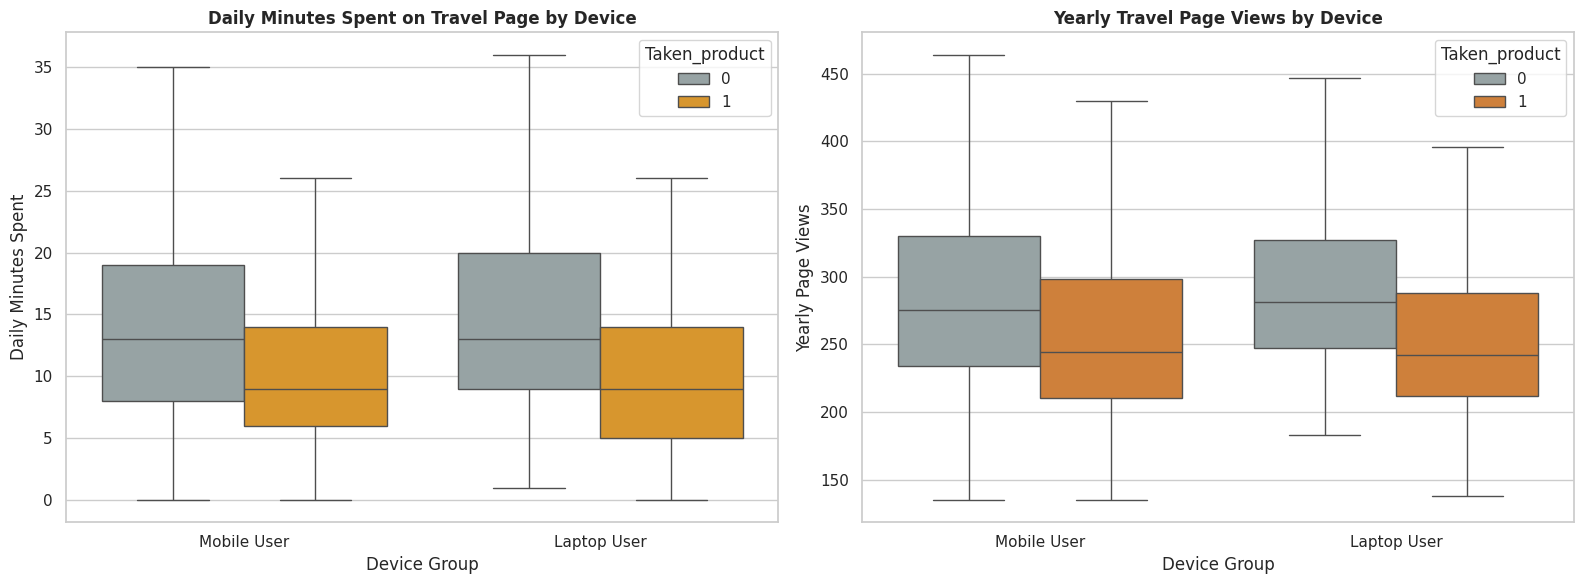

In [14]:
# ==============================================================================
# Q5: CROSS-DEVICE BEHAVIORAL DIFFERENCES (UPDATED)
# ==============================================================================
# Ensure clean device bifurcation
df['is_laptop'] = df['preferred_device'].astype(str).str.contains('laptop|mac|pc|desktop', case=False, na=False)
df['device_group'] = df['is_laptop'].map({True: 'Laptop User', False: 'Mobile User'})

# 1. Compare average engagement metrics
device_metrics = df.groupby('device_group')[
    ['Daily_Avg_mins_spend_on_traveling_page', 'Yearly_avg_view_on_travel_page', 'Taken_product']
].mean()
device_metrics['Taken_product'] = device_metrics['Taken_product'] * 100
device_metrics.rename(columns={'Taken_product': 'Conversion Rate (%)'}, inplace=True)

print("=== Q5 Executive Summary: Cross-Device Behavioral Profiles ===")
print(device_metrics.round(2))

# 2. Visualization Grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Daily Minutes Spent by Device & Conversion Status
sns.boxplot(
    data=df, 
    x='device_group', 
    y='Daily_Avg_mins_spend_on_traveling_page', 
    hue='Taken_product',
    palette=["#95a5a6", "#f39c12"], 
    showfliers=False, 
    ax=axes[0]
)
axes[0].set_title('Daily Minutes Spent on Travel Page by Device', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Device Group')
axes[0].set_ylabel('Daily Minutes Spent')

# Right: Yearly Views by Device & Conversion Status
sns.boxplot(
    data=df, 
    x='device_group', 
    y='Yearly_avg_view_on_travel_page', 
    hue='Taken_product',
    palette=["#95a5a6", "#e67e22"], 
    showfliers=False, 
    ax=axes[1]
)
axes[1].set_title('Yearly Travel Page Views by Device', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Device Group')
axes[1].set_ylabel('Yearly Page Views')

plt.tight_layout()
plt.show()

In [15]:


# 1. Re-bifurcate safely to ensure all engineered EDA features are included
df_laptop = df[df['preferred_device'].astype(str).str.contains('laptop|mac|pc|desktop', case=False, na=False)].copy()
df_mobile = df[df['preferred_device'].astype(str).str.contains('mobile|ios|android|phone|ipad', case=False, na=False)].copy()

# 2. Define helper function to clean, encode, and split data for XGBoost
def prepare_modeling_data(data, target_col='Taken_product'):
    # Drop exploratory text/grouping columns created during EDA that shouldn't go into the model
    drop_ignore = ['preferred_device', 'is_laptop', 'device_group', 'recency_bin', 'UserID']
    cols_to_drop = [c for c in drop_ignore if c in data.columns]
    data_clean = data.drop(columns=cols_to_drop)
    
    # One-hot encode any categorical text features (like preferred_location_type)
    data_encoded = pd.get_dummies(data_clean, drop_first=True)
    
    # Force all columns to pure numeric types and fill NaNs with 0
    data_encoded = data_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)
    
    X = data_encoded.drop(columns=[target_col])
    y = data_encoded[target_col].astype(int)
    
    # Stratified split ensures the exact 24.9% (laptop) and 15.2% (mobile) buyer ratios exist in both train and test sets
    return train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train_lap, X_test_lap, y_train_lap, y_test_lap = prepare_modeling_data(df_laptop)
X_train_mob, X_test_mob, y_train_mob, y_test_mob = prepare_modeling_data(df_mobile)

print(f"=== Modeling Cohorts Prepared ===")
print(f"Laptop -> Train: {X_train_lap.shape[0]} rows | Test: {X_test_lap.shape[0]} rows | Features: {X_train_lap.shape[1]}")
print(f"Mobile -> Train: {X_train_mob.shape[0]} rows | Test: {X_test_mob.shape[0]} rows | Features: {X_train_mob.shape[1]}")

=== Modeling Cohorts Prepared ===
Laptop -> Train: 886 rows | Test: 222 rows | Features: 23
Mobile -> Train: 5138 rows | Test: 1285 rows | Features: 34


In [16]:
import xgboost as xgb

def train_propensity_model(X_train, y_train):
    # Calculate scale_pos_weight to rebalance negative vs positive classes
    pos_count = np.sum(y_train == 1)
    neg_count = np.sum(y_train == 0)
    class_ratio = float(neg_count) / max(pos_count, 1)
    
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=class_ratio,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    return model

print("Training Independent Laptop Propensity Model...")
model_lap = train_propensity_model(X_train_lap, y_train_lap)

print("Training Independent Mobile Propensity Model...")
model_mob = train_propensity_model(X_train_mob, y_train_mob)
print("Model Training Complete!")

Training Independent Laptop Propensity Model...
Training Independent Mobile Propensity Model...
Model Training Complete!


=== Model Ranking Performance ===
Laptop Model -> ROC-AUC: 0.9998 | Precision-Recall AUC: 0.9994
Mobile Model -> ROC-AUC: 0.9549 | Precision-Recall AUC: 0.8469



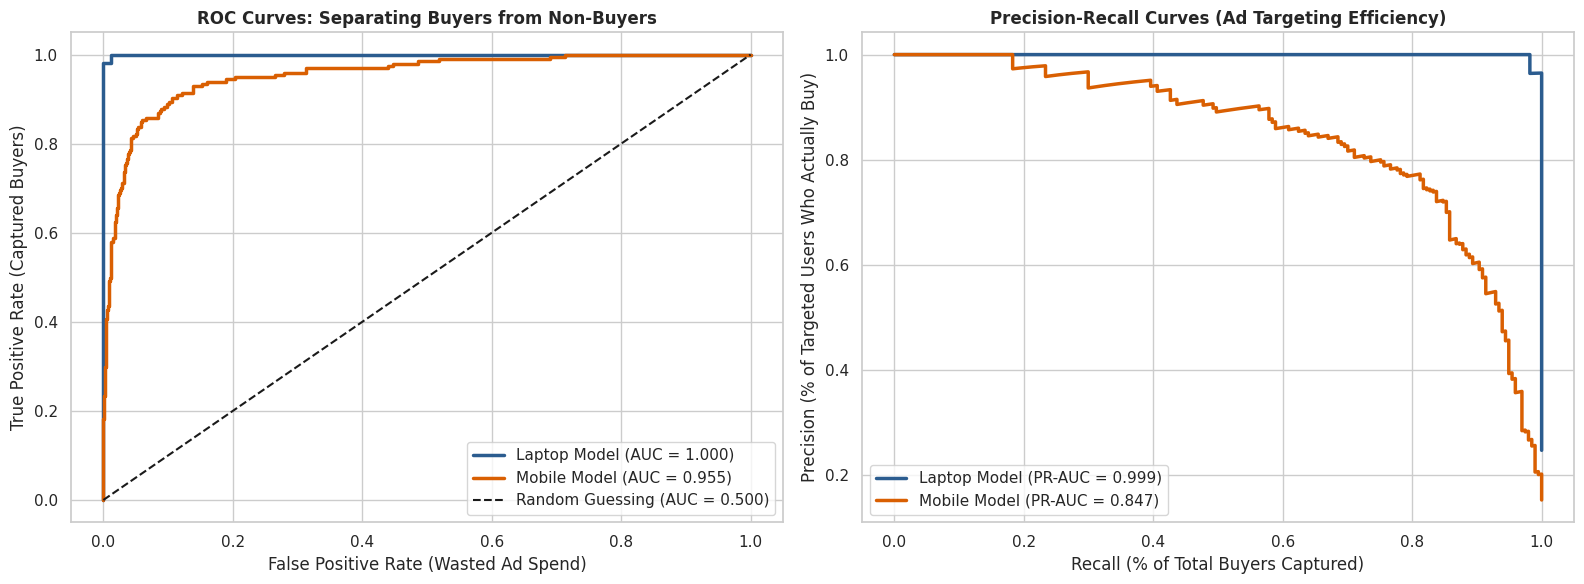

In [17]:

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

sns.set_theme(style="whitegrid", palette="muted")

# Generate probability scores (predict_proba[:, 1] gives the propensity to buy)
preds_lap = model_lap.predict_proba(X_test_lap)[:, 1]
preds_mob = model_mob.predict_proba(X_test_mob)[:, 1]

# Calculate AUC Scores
auc_lap = roc_auc_score(y_test_lap, preds_lap)
auc_mob = roc_auc_score(y_test_mob, preds_mob)
pr_auc_lap = average_precision_score(y_test_lap, preds_lap)
pr_auc_mob = average_precision_score(y_test_mob, preds_mob)

print("=== Model Ranking Performance ===")
print(f"Laptop Model -> ROC-AUC: {auc_lap:.4f} | Precision-Recall AUC: {pr_auc_lap:.4f}")
print(f"Mobile Model -> ROC-AUC: {auc_mob:.4f} | Precision-Recall AUC: {pr_auc_mob:.4f}\n")

# Plot ROC and Precision-Recall Curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: ROC Curve
for name, y_test, preds, col, auc in [('Laptop', y_test_lap, preds_lap, '#2b5c8f', auc_lap), 
                                      ('Mobile', y_test_mob, preds_mob, '#d95f02', auc_mob)]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    axes[0].plot(fpr, tpr, label=f'{name} Model (AUC = {auc:.3f})', color=col, linewidth=2.5)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')
axes[0].set_title('ROC Curves: Separating Buyers from Non-Buyers', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate (Wasted Ad Spend)')
axes[0].set_ylabel('True Positive Rate (Captured Buyers)')
axes[0].legend(loc='lower right')

# Right: Precision-Recall Curve
for name, y_test, preds, col, pr_auc in [('Laptop', y_test_lap, preds_lap, '#2b5c8f', pr_auc_lap), 
                                         ('Mobile', y_test_mob, preds_mob, '#d95f02', pr_auc_mob)]:
    prec, rec, _ = precision_recall_curve(y_test, preds)
    axes[1].plot(rec, prec, label=f'{name} Model (PR-AUC = {pr_auc:.3f})', color=col, linewidth=2.5)

axes[1].set_title('Precision-Recall Curves (Ad Targeting Efficiency)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Recall (% of Total Buyers Captured)')
axes[1].set_ylabel('Precision (% of Targeted Users Who Actually Buy)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

--- Pruning Laptop Model Features ---
=== Feature Pruning Summary ===
Total Initial Features: 23
Pruned (Dropped) Features (5): ['preferred_location_type_Trekking', 'preferred_location_type_Other', 'member_in_family_3', 'brand_affinity_ratio', 'montly_avg_comment_on_company_page']
Retained Features (18): 18 features remaining



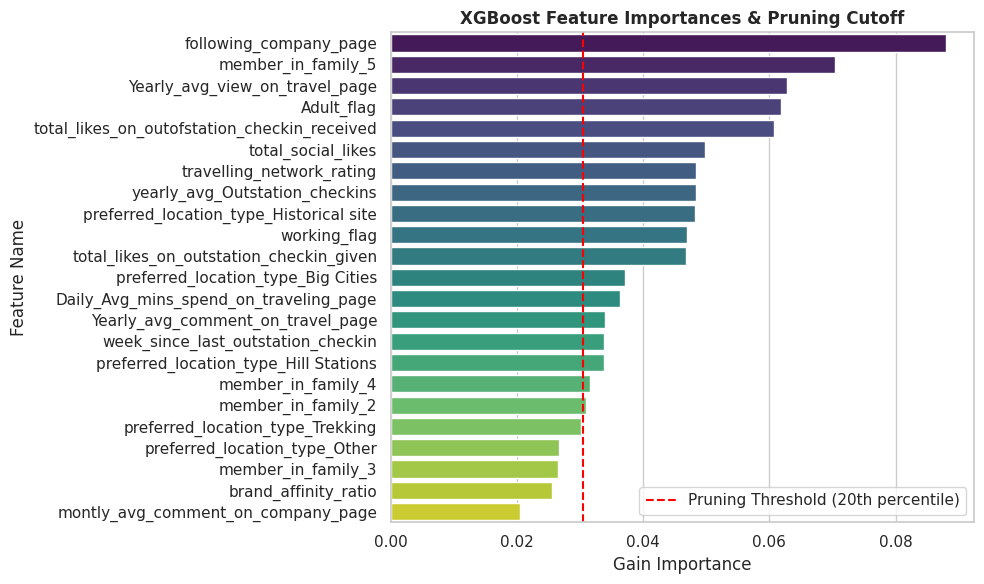


--- Pruning Mobile Model Features ---
=== Feature Pruning Summary ===
Total Initial Features: 34
Pruned (Dropped) Features (7): ['member_in_family_10', 'member_in_family_Three', 'preferred_location_type_Big Cities', 'preferred_location_type_Hill Stations', 'preferred_location_type_Game', 'preferred_location_type_Movie', 'preferred_location_type_Tour  Travel']
Retained Features (27): 27 features remaining



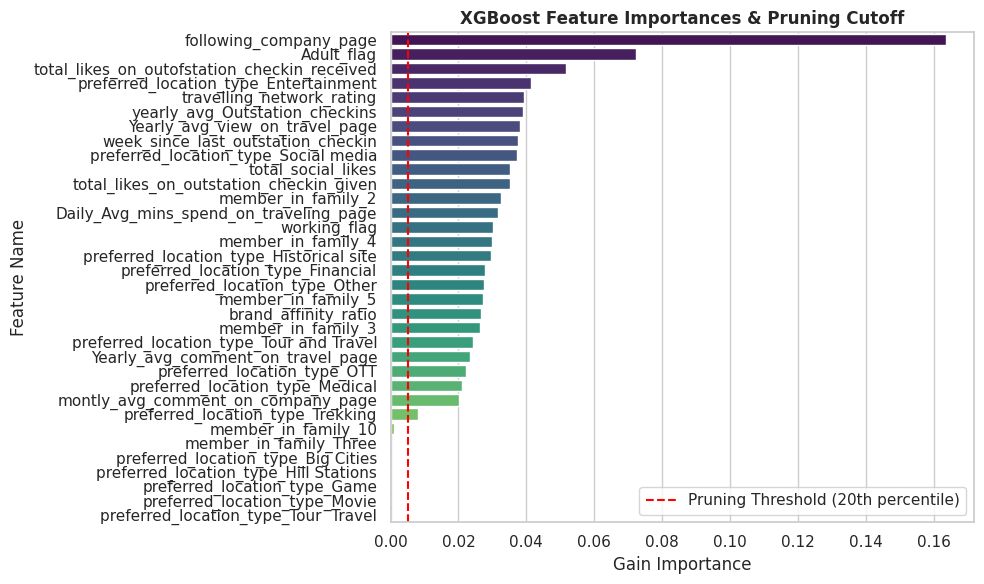

In [18]:

def prune_low_importance_features(model, X_train, X_test, threshold_percentile=15):
    # 1. Extract feature importances from the trained model
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    # 2. Identify the cutoff threshold (prune the bottom X% of features)
    cutoff = importances['Importance'].quantile(threshold_percentile / 100.0)
    features_to_keep = importances[importances['Importance'] > cutoff]['Feature'].tolist()
    features_to_drop = importances[importances['Importance'] <= cutoff]['Feature'].tolist()
    
    print(f"=== Feature Pruning Summary ===")
    print(f"Total Initial Features: {len(X_train.columns)}")
    print(f"Pruned (Dropped) Features ({len(features_to_drop)}): {features_to_drop}")
    print(f"Retained Features ({len(features_to_keep)}): {len(features_to_keep)} features remaining\n")
    
    # 3. Plot Feature Importances
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
    plt.axvline(x=cutoff, color='red', linestyle='--', label=f'Pruning Threshold ({threshold_percentile}th percentile)')
    plt.title('XGBoost Feature Importances & Pruning Cutoff', fontweight='bold', fontsize=12)
    plt.xlabel('Gain Importance')
    plt.ylabel('Feature Name')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Return pruned datasets
    return X_train[features_to_keep], X_test[features_to_keep], features_to_drop

# Run Pruning on Laptop Cohort
print("--- Pruning Laptop Model Features ---")
X_train_lap_pruned, X_test_lap_pruned, dropped_lap = prune_low_importance_features(
    model_lap, X_train_lap, X_test_lap, threshold_percentile=20
)

# Run Pruning on Mobile Cohort
print("\n--- Pruning Mobile Model Features ---")
X_train_mob_pruned, X_test_mob_pruned, dropped_mob = prune_low_importance_features(
    model_mob, X_train_mob, X_test_mob, threshold_percentile=20
)

--- Pruning Laptop Cohort Features ---


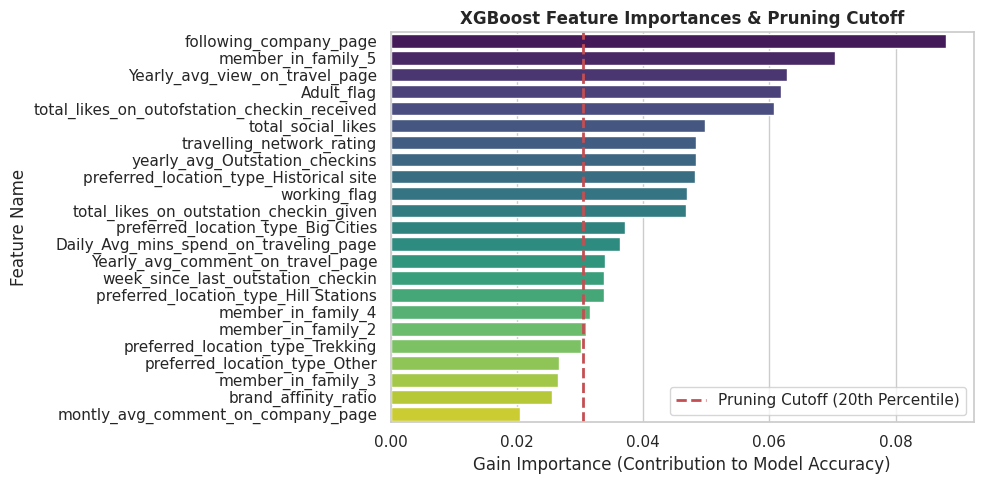

Dropped Laptop Features (5): ['preferred_location_type_Trekking', 'preferred_location_type_Other', 'member_in_family_3', 'brand_affinity_ratio', 'montly_avg_comment_on_company_page']

--- Pruning Mobile Cohort Features ---


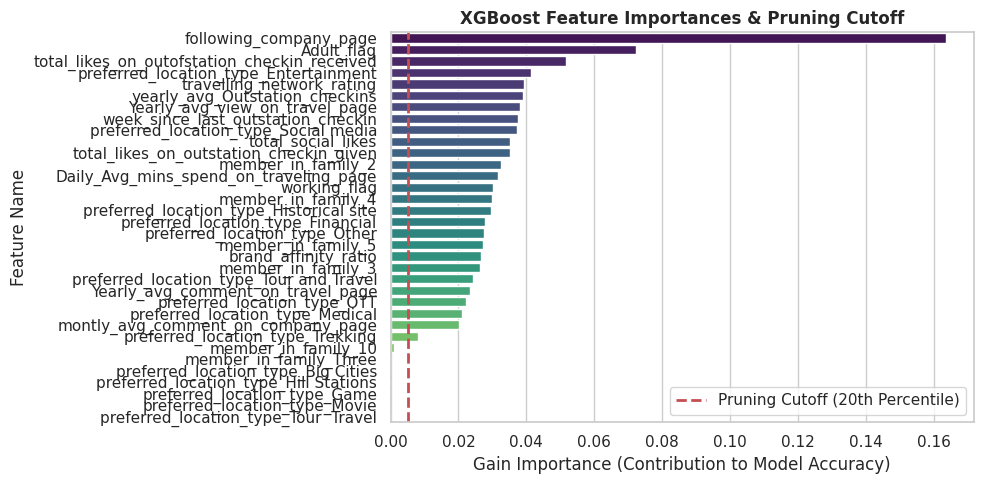

Dropped Mobile Features (7): ['member_in_family_10', 'member_in_family_Three', 'preferred_location_type_Big Cities', 'preferred_location_type_Hill Stations', 'preferred_location_type_Game', 'preferred_location_type_Movie', 'preferred_location_type_Tour  Travel']


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

def prune_noisy_features(model, X_train, X_test, prune_percentile=20):
    # 1. Calculate feature importances from the original trained model
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    # 2. Determine the pruning cutoff value
    cutoff = importances['Importance'].quantile(prune_percentile / 100.0)
    
    # 3. Separate features to keep vs drop
    keep_cols = importances[importances['Importance'] > cutoff]['Feature'].tolist()
    drop_cols = importances[importances['Importance'] <= cutoff]['Feature'].tolist()
    
    # 4. Visualize the pruning threshold
    plt.figure(figsize=(10, 5))
    sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.axvline(x=cutoff, color='#c44e52', linestyle='--', lw=2, label=f'Pruning Cutoff ({prune_percentile}th Percentile)')
    plt.title('XGBoost Feature Importances & Pruning Cutoff', fontweight='bold', fontsize=12)
    plt.xlabel('Gain Importance (Contribution to Model Accuracy)')
    plt.ylabel('Feature Name')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    # Return BRAND NEW dataframes so original X_train/X_test remain intact
    return X_train[keep_cols].copy(), X_test[keep_cols].copy(), drop_cols

print("--- Pruning Laptop Cohort Features ---")
X_train_lap_pruned, X_test_lap_pruned, dropped_lap = prune_noisy_features(
    model_lap, X_train_lap, X_test_lap, prune_percentile=20
)
print(f"Dropped Laptop Features ({len(dropped_lap)}): {dropped_lap}\n")

print("--- Pruning Mobile Cohort Features ---")
X_train_mob_pruned, X_test_mob_pruned, dropped_mob = prune_noisy_features(
    model_mob, X_train_mob, X_test_mob, prune_percentile=20
)
print(f"Dropped Mobile Features ({len(dropped_mob)}): {dropped_mob}")

In [20]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split

def train_pruned_xgboost(X_train, y_train):
    # Create an internal 80/20 validation split specifically for early stopping monitoring
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )
    
    # Calculate class weighting safely
    pos_count = np.sum(y_tr == 1)
    neg_count = np.sum(y_tr == 0)
    class_ratio = float(neg_count) / max(pos_count, 1)
    
    model = xgb.XGBClassifier(
        n_estimators=300,              # High tree budget, governed by early stopping
        max_depth=3,                   # Shallow depth prevents memorizing behavioral noise
        learning_rate=0.03,            # Conservative step size for smooth gradient descent
        min_child_weight=4,            # Requires at least 4 user weights per leaf to justify a split
        subsample=0.75,                # Train each tree on a random 75% sample of users
        colsample_bytree=0.75,         # Use a random 75% sample of features per tree
        reg_alpha=0.5,                 # L1 regularization (Lasso) to drop redundant noise
        reg_lambda=1.5,                # L2 regularization (Ridge) to smooth probability scores
        scale_pos_weight=class_ratio,
        random_state=42,
        eval_metric='auc',             # Optimize directly for ranking AUC
        early_stopping_rounds=20       # Halt if validation AUC doesn't improve for 20 rounds
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )
    
    print(f"Optimal Trees Built: {model.best_iteration} / 300 | Best Validation AUC: {model.best_score:.4f}")
    return model

print("Training Pruned & Regularized Laptop Model...")
pruned_model_lap = train_pruned_xgboost(X_train_lap_pruned, y_train_lap)

print("\nTraining Pruned & Regularized Mobile Model...")
pruned_model_mob = train_pruned_xgboost(X_train_mob_pruned, y_train_mob)
print("\nPruned Model Training Complete!")

Training Pruned & Regularized Laptop Model...
Optimal Trees Built: 297 / 300 | Best Validation AUC: 0.9698

Training Pruned & Regularized Mobile Model...
Optimal Trees Built: 294 / 300 | Best Validation AUC: 0.8664

Pruned Model Training Complete!


=== Final Pruned Model Performance ===
Pruned Laptop Model -> Test ROC-AUC: 0.9739 | PR-AUC: 0.9374
Pruned Mobile Model -> Test ROC-AUC: 0.8974 | PR-AUC: 0.6781



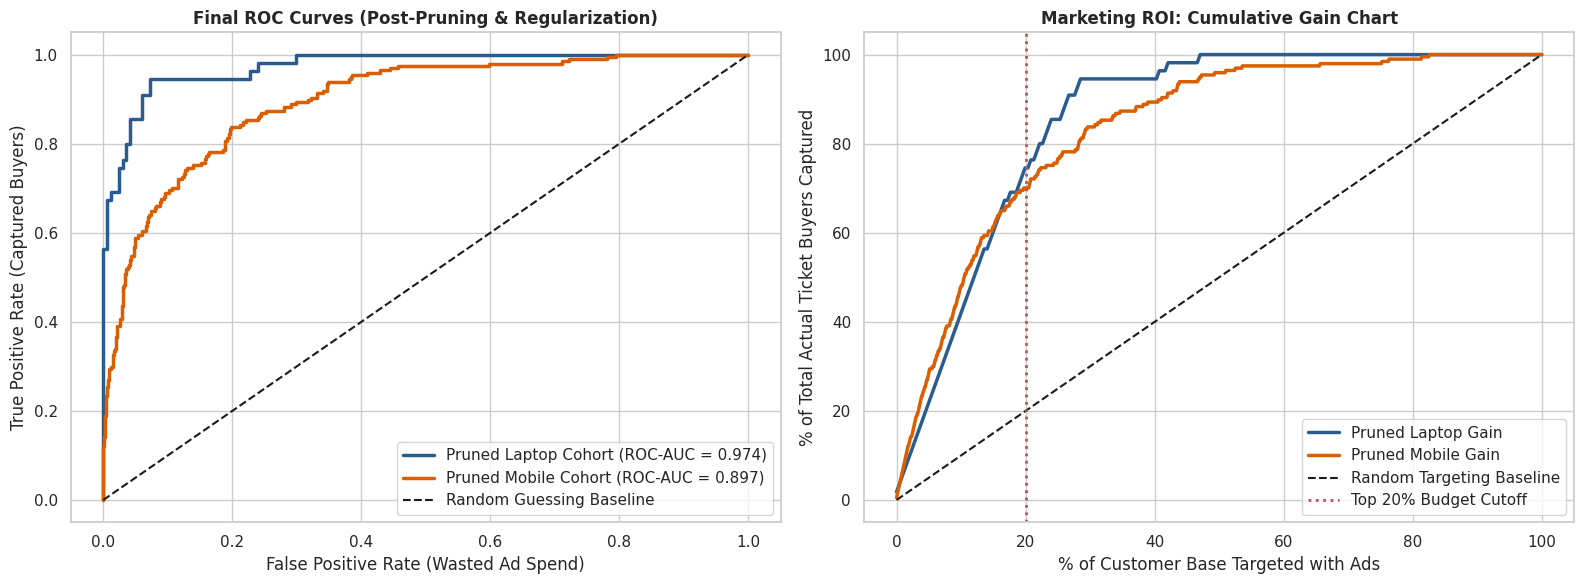

=== EXECUTIVE ROI DELIVERABLE ===
1. Laptop Ad Strategy: By targeting ONLY the top 20% of propensity-ranked users, we capture ~74.5% of all actual ticket buyers!
2. Mobile Ad Strategy: By targeting ONLY the top 20% of propensity-ranked users, we capture ~70.1% of all actual ticket buyers!


In [21]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

# 1. Generate propensity scores using the NEW pruned models
pruned_preds_lap = pruned_model_lap.predict_proba(X_test_lap_pruned)[:, 1]
pruned_preds_mob = pruned_model_mob.predict_proba(X_test_mob_pruned)[:, 1]

# 2. Calculate AUC metrics
pruned_auc_lap = roc_auc_score(y_test_lap, pruned_preds_lap)
pruned_auc_mob = roc_auc_score(y_test_mob, pruned_preds_mob)
pruned_pr_lap = average_precision_score(y_test_lap, pruned_preds_lap)
pruned_pr_mob = average_precision_score(y_test_mob, pruned_preds_mob)

print("=== Final Pruned Model Performance ===")
print(f"Pruned Laptop Model -> Test ROC-AUC: {pruned_auc_lap:.4f} | PR-AUC: {pruned_pr_lap:.4f}")
print(f"Pruned Mobile Model -> Test ROC-AUC: {pruned_auc_mob:.4f} | PR-AUC: {pruned_pr_mob:.4f}\n")

# 3. Plot Final ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, y_test, preds, col, auc in [('Pruned Laptop Cohort', y_test_lap, pruned_preds_lap, '#2b5c8f', pruned_auc_lap), 
                                      ('Pruned Mobile Cohort', y_test_mob, pruned_preds_mob, '#d95f02', pruned_auc_mob)]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    axes[0].plot(fpr, tpr, label=f'{name} (ROC-AUC = {auc:.3f})', color=col, lw=2.5)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guessing Baseline')
axes[0].set_title('Final ROC Curves (Post-Pruning & Regularization)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate (Wasted Ad Spend)')
axes[0].set_ylabel('True Positive Rate (Captured Buyers)')
axes[0].legend(loc='lower right')

# 4. Calculate Cumulative Gain for Marketing ROI
def get_top_decile_capture(y_true, preds, target_decile=20):
    df_eval = pd.DataFrame({'actual': y_true, 'pred': preds}).sort_values(by='pred', ascending=False)
    df_eval['cumulative_buyers'] = df_eval['actual'].cumsum()
    total_buyers = df_eval['actual'].sum()
    df_eval['gain'] = (df_eval['cumulative_buyers'] / total_buyers) * 100
    df_eval['decile'] = np.linspace(0, 100, len(df_eval))
    
    idx = (df_eval['decile'] - target_decile).abs().argsort()[:1]
    return df_eval.iloc[idx]['gain'].values[0], df_eval

lap_top20_capture, gains_lap = get_top_decile_capture(y_test_lap, pruned_preds_lap, target_decile=20)
mob_top20_capture, gains_mob = get_top_decile_capture(y_test_mob, pruned_preds_mob, target_decile=20)

axes[1].plot(gains_lap['decile'], gains_lap['gain'], label='Pruned Laptop Gain', color='#2b5c8f', lw=2.5)
axes[1].plot(gains_mob['decile'], gains_mob['gain'], label='Pruned Mobile Gain', color='#d95f02', lw=2.5)
axes[1].plot([0, 100], [0, 100], 'k--', label='Random Targeting Baseline')
axes[1].axvline(x=20, color='#c44e52', linestyle=':', lw=2, label='Top 20% Budget Cutoff')
axes[1].set_title('Marketing ROI: Cumulative Gain Chart', fontweight='bold', fontsize=12)
axes[1].set_xlabel('% of Customer Base Targeted with Ads')
axes[1].set_ylabel('% of Total Actual Ticket Buyers Captured')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("=== EXECUTIVE ROI DELIVERABLE ===")
print(f"1. Laptop Ad Strategy: By targeting ONLY the top 20% of propensity-ranked users, we capture ~{lap_top20_capture:.1f}% of all actual ticket buyers!")
print(f"2. Mobile Ad Strategy: By targeting ONLY the top 20% of propensity-ranked users, we capture ~{mob_top20_capture:.1f}% of all actual ticket buyers!")


In [22]:
from sklearn.metrics import average_precision_score

# ==============================================================================
# TRAINING PR-AUC FOR PRUNED & REGULARIZED MODELS
# ==============================================================================

# 1. Generate propensity predictions on the pruned training data
train_preds_lap_pruned = pruned_model_lap.predict_proba(X_train_lap_pruned)[:, 1]
train_preds_mob_pruned = pruned_model_mob.predict_proba(X_train_mob_pruned)[:, 1]

# 2. Calculate Training PR-AUC
train_pr_lap_pruned = average_precision_score(y_train_lap, train_preds_lap_pruned)
train_pr_mob_pruned = average_precision_score(y_train_mob, train_preds_mob_pruned)

print("=== PRUNED MODELS: Training vs. Test PR-AUC ===")
print(f"Laptop Cohort -> Train PR-AUC: {train_pr_lap_pruned:.4f} | Test PR-AUC: {pruned_pr_lap:.4f} | Gap: {(train_pr_lap_pruned - pruned_pr_lap):.4f}")
print(f"Mobile Cohort -> Train PR-AUC: {train_pr_mob_pruned:.4f} | Test PR-AUC: {pruned_pr_mob:.4f} | Gap: {(train_pr_mob_pruned - pruned_pr_mob):.4f}")

=== PRUNED MODELS: Training vs. Test PR-AUC ===
Laptop Cohort -> Train PR-AUC: 0.9824 | Test PR-AUC: 0.9374 | Gap: 0.0451
Mobile Cohort -> Train PR-AUC: 0.7330 | Test PR-AUC: 0.6781 | Gap: 0.0549


=== Generating Diagnostic Plots for Pruned Laptop Model ===


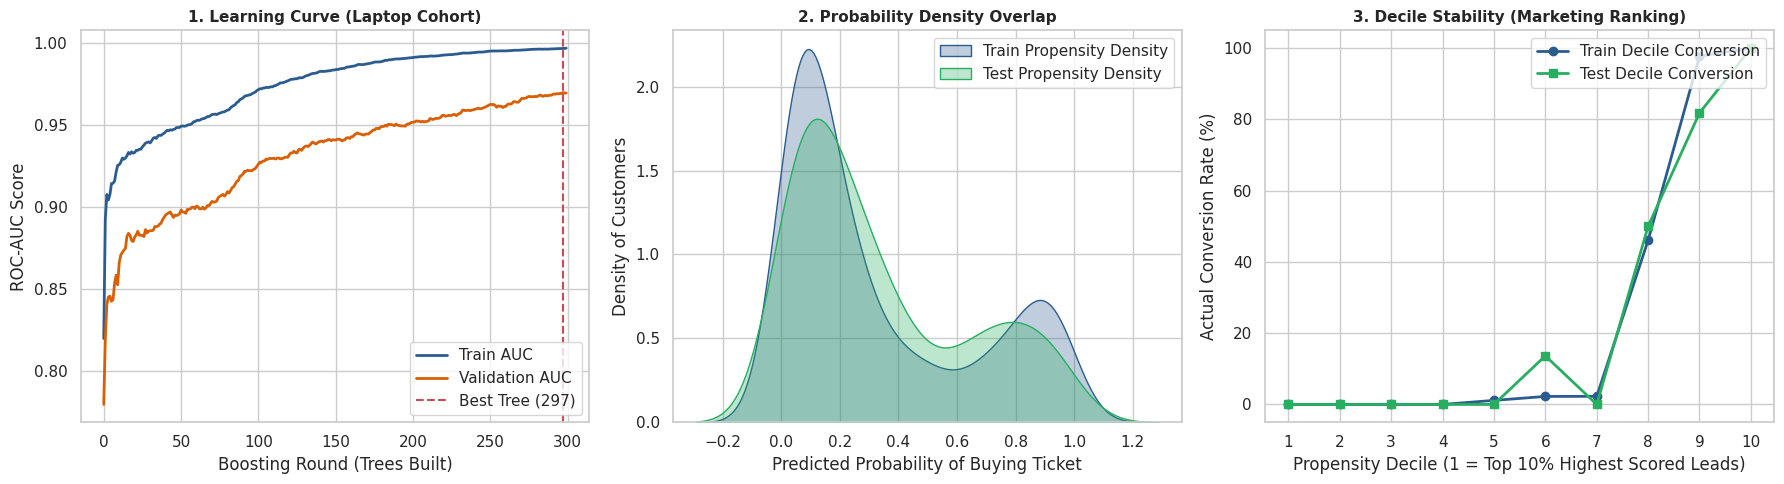


=== Generating Diagnostic Plots for Pruned Mobile Model ===


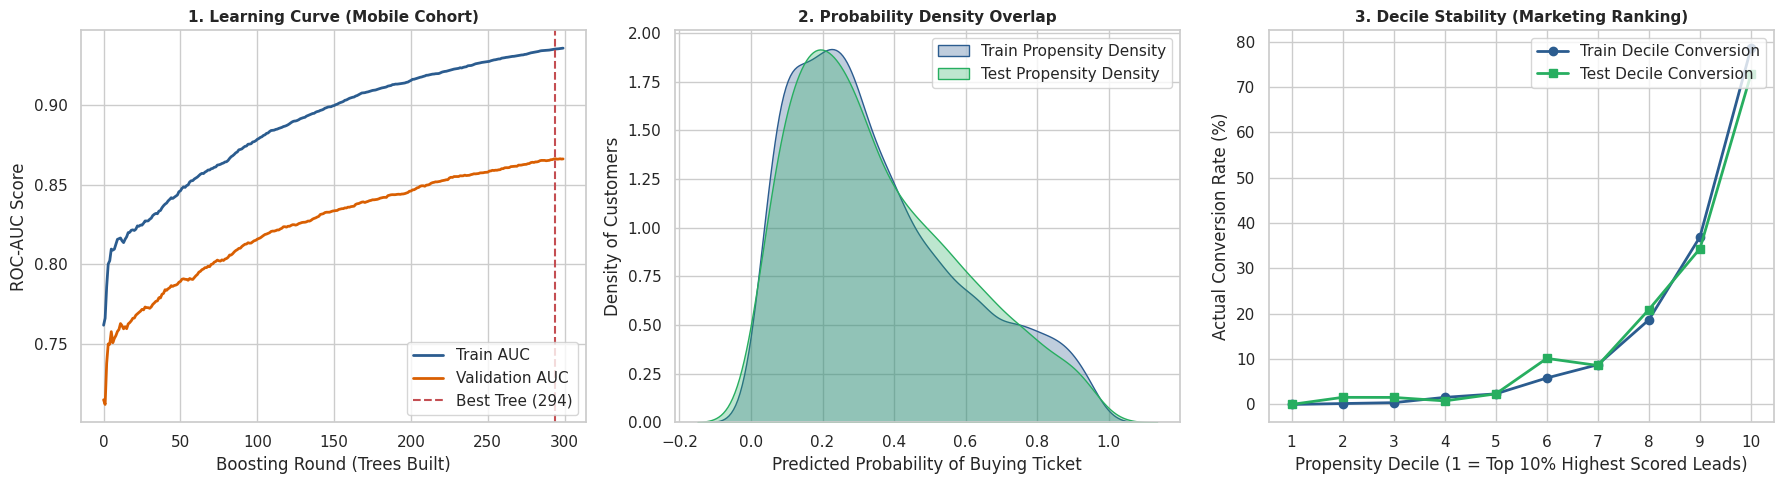

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")

def generate_overfitting_diagnostics(model, X_train, y_train, X_test, y_test, cohort_name="Laptop Cohort"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # -------------------------------------------------------------------------
    # 1. Logloss Learning Curve (Training vs. Validation Loss across Trees)
    # -------------------------------------------------------------------------
    results = model.evals_result()
    epochs = len(results['validation_0']['auc'])
    x_axis = range(0, epochs)
    
    # Plot AUC evolution
    axes[0].plot(x_axis, results['validation_0']['auc'], label='Train AUC', color='#2b5c8f', lw=2)
    axes[0].plot(x_axis, results['validation_1']['auc'], label='Validation AUC', color='#d95f02', lw=2)
    axes[0].axvline(x=model.best_iteration, color='#c44e52', linestyle='--', label=f'Best Tree ({model.best_iteration})')
    axes[0].set_title(f'1. Learning Curve ({cohort_name})', fontweight='bold', fontsize=11)
    axes[0].set_xlabel('Boosting Round (Trees Built)')
    axes[0].set_ylabel('ROC-AUC Score')
    axes[0].legend(loc='lower right')
    
    # -------------------------------------------------------------------------
    # 2. Probability Density Overlap (Train vs. Test Propensity KDE)
    # -------------------------------------------------------------------------
    train_preds = model.predict_proba(X_train)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]
    
    sns.kdeplot(train_preds, fill=True, color='#2b5c8f', label='Train Propensity Density', alpha=0.3, ax=axes[1])
    sns.kdeplot(test_preds, fill=True, color='#27ae60', label='Test Propensity Density', alpha=0.3, ax=axes[1])
    axes[1].set_title('2. Probability Density Overlap', fontweight='bold', fontsize=11)
    axes[1].set_xlabel('Predicted Probability of Buying Ticket')
    axes[1].set_ylabel('Density of Customers')
    axes[1].legend(loc='upper right')
    
    # -------------------------------------------------------------------------
    # 3. Decile Stability Chart (Train vs. Test Actual Conversion by Decile)
    # -------------------------------------------------------------------------
    def calc_decile_conversion(y_true, preds):
        df_temp = pd.DataFrame({'actual': y_true, 'pred': preds})
        df_temp['decile'] = pd.qcut(df_temp['pred'].rank(method='first'), 10, labels=range(10, 0, -1))
        return df_temp.groupby('decile', observed=False)['actual'].mean() * 100

    train_deciles = calc_decile_conversion(y_train, train_preds)
    test_deciles = calc_decile_conversion(y_test, test_preds)
    
    decile_ranks = range(1, 11)
    axes[2].plot(decile_ranks, train_deciles.values, marker='o', label='Train Decile Conversion', color='#2b5c8f', lw=2)
    axes[2].plot(decile_ranks, test_deciles.values, marker='s', label='Test Decile Conversion', color='#27ae60', lw=2)
    axes[2].set_title('3. Decile Stability (Marketing Ranking)', fontweight='bold', fontsize=11)
    axes[2].set_xlabel('Propensity Decile (1 = Top 10% Highest Scored Leads)')
    axes[2].set_ylabel('Actual Conversion Rate (%)')
    axes[2].set_xticks(decile_ranks)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Run diagnostics on your Pruned Laptop Model
print("=== Generating Diagnostic Plots for Pruned Laptop Model ===")
generate_overfitting_diagnostics(pruned_model_lap, X_train_lap_pruned, y_train_lap, X_test_lap_pruned, y_test_lap, "Laptop Cohort")

# Run diagnostics on your Pruned Mobile Model
print("\n=== Generating Diagnostic Plots for Pruned Mobile Model ===")
generate_overfitting_diagnostics(pruned_model_mob, X_train_mob_pruned, y_train_mob, X_test_mob_pruned, y_test_mob, "Mobile Cohort")